In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_100k.csv")
#df

In [3]:
remove_attributes = []
for c in df["themes"]:
    remove_attributes.extend(c.split(" "))

In [4]:
y = df["rating"]
X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"] + remove_attributes)
#X

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(69335, 40)
(69335,)
(29716, 40)
(29716,)


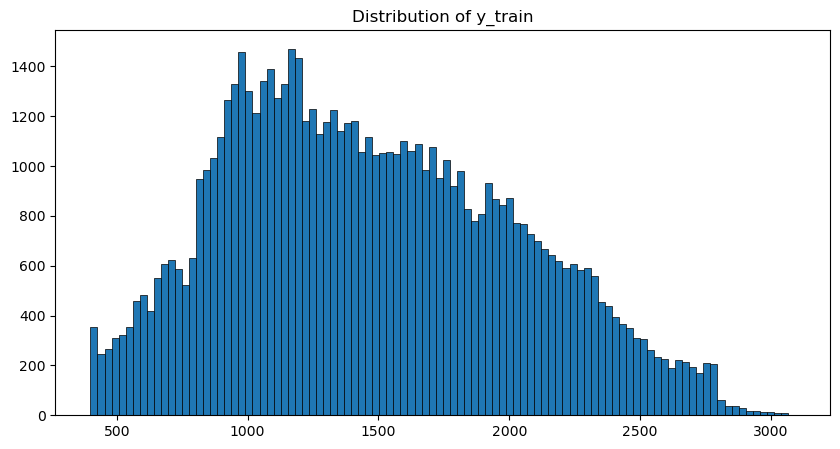

In [6]:
plt.figure(figsize=(10,5))
plt.hist(y_train, bins=100, edgecolor="black", linewidth=0.5)
plt.title("Distribution of y_train")
plt.show()

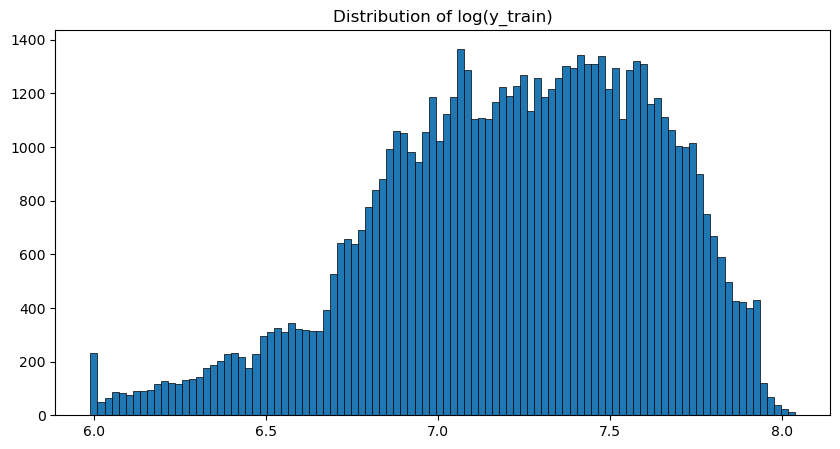

In [7]:
plt.figure(figsize=(10,5))
plt.hist(np.log(y_train), bins=100, edgecolor="black", linewidth=0.5)
plt.title("Distribution of log(y_train)")
plt.show()

In [8]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="yeo-johnson")
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()

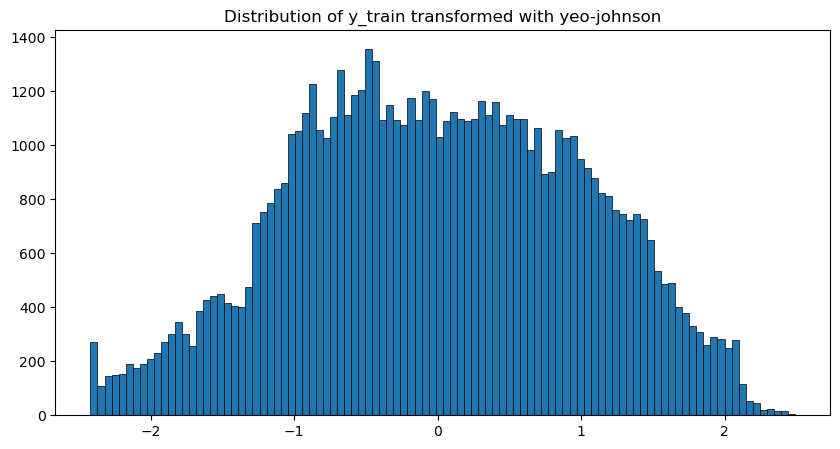

In [9]:
plt.figure(figsize=(10,5))
plt.hist(y_train_transformed, bins=100, edgecolor="black", linewidth=0.5)
plt.title("Distribution of y_train transformed with yeo-johnson")
plt.show()

In [12]:
from sklearn.preprocessing import QuantileTransformer
uniform = QuantileTransformer(output_distribution="uniform")
y_train_transformed = uniform.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()

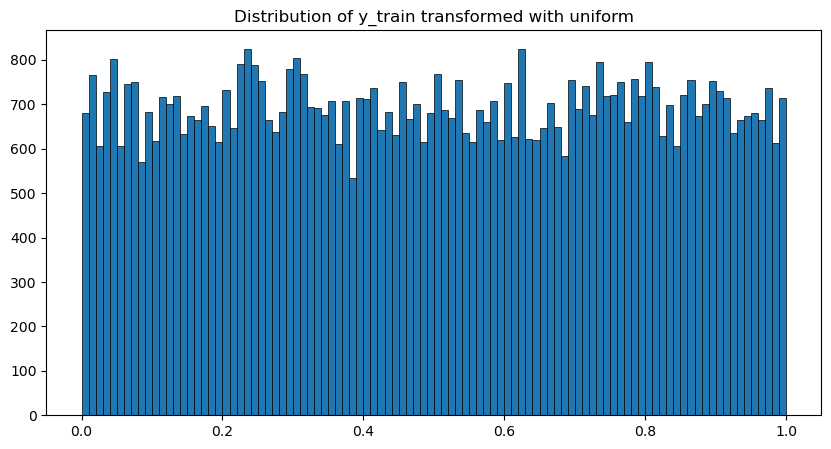

In [13]:
plt.figure(figsize=(10,5))
plt.hist(y_train_transformed, bins=100, edgecolor="black", linewidth=0.5)
plt.title("Distribution of y_train transformed with uniform")
plt.show()